# CLV - uscrime dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## uscrime dataset

In [2]:
# poison dataset
from clustvartools.datasets import uscrime
data = uscrime.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crime.rate       47 non-null     float64
 1   Male14_24        47 non-null     int64  
 2   Southern.states  47 non-null     int64  
 3   Education        47 non-null     int64  
 4   Expend60         47 non-null     int64  
 5   Expend59         47 non-null     int64  
 6   Labor.force      47 non-null     int64  
 7   Male             47 non-null     int64  
 8   Pop.size         47 non-null     int64  
 9   Non.white        47 non-null     int64  
 10  Unemp14_24       47 non-null     int64  
 11  Unemp35_39       47 non-null     int64  
 12  Family.Income    47 non-null     int64  
 13  Under.median     47 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 5.3 KB


## Instanciation and training

In [3]:
# instanciation
from clustvartools import CLV
clf = CLV(ncl=4,sup_var=0)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,ncl,4
,sup_var,0
,row_w,None
,tol,1e-07
Name,Type,Value
call_,call,call(Xtot= ...'Crime.rate'])
cluster_,cluster,cluster(summa...485 0.004941)
coef_,coef,coef(coef= ...NaN -0.209105)
quanti_var_,quanti_var,quanti_var(cl...NaN -0.438878)
var_sup_,var_sup,var_sup(clust... 0.609862)


### `fit_transform` function

In [5]:
# fit_transform function - cluster squared loadings
sqload = clf.fit_transform(data)
sqload

,1,2,3,4
Male14_24,0.063053,0.247323,0.011879,0.598762
Southern.states,0.002906,0.101113,0.222235,0.744078
Education,0.011179,0.153682,0.329088,0.739636
Expend60,0.005726,0.933402,0.007963,0.343590
Expend59,0.003955,0.926061,0.005514,0.356929
Labor.force,0.121056,0.002978,0.756779,0.173767
Male,0.031795,0.010377,0.756779,0.081126
Pop.size,0.015454,0.524850,0.094306,0.015853
Non.white,0.001634,0.021310,0.147638,0.694397
Unemp14_24,0.872962,0.002516,0.004957,0.016550


### `transform` function

In [6]:
# transform function - cluster squared loadings
sqload = clf.transform(uscrime.actif)
sqload

,1,2,3,4
Male14_24,0.063053,0.247323,0.011879,0.598762
Southern.states,0.002906,0.101113,0.222235,0.744078
Education,0.011179,0.153682,0.329088,0.739636
Expend60,0.005726,0.933402,0.007963,0.343590
Expend59,0.003955,0.926061,0.005514,0.356929
Labor.force,0.121056,0.002978,0.756779,0.173767
Male,0.031795,0.010377,0.756779,0.081126
Pop.size,0.015454,0.524850,0.094306,0.015853
Non.white,0.001634,0.021310,0.147638,0.694397
Unemp14_24,0.872962,0.002516,0.004957,0.016550


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
Male14_24,4
Southern.states,4
Education,4
Expend60,2
Expend59,2
Labor.force,3
Male,3
Pop.size,2
Non.white,4
Unemp14_24,1


### `predict` function

In [8]:
# predict function
prediction = clf.predict(uscrime.actif)
prediction.to_frame()

,cluster
Male14_24,4
Southern.states,4
Education,4
Expend60,2
Expend59,2
Labor.force,3
Male,3
Pop.size,2
Non.white,4
Unemp14_24,1


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - CLV**

*The results are available in the following objects:

name          description
------------  ------------------------------------
.call_        summary called parameters
.cluster_     results for clusters
.coef_        Coefficients
.quanti_var_  results for the continuous variables
.var_sup_     results for supplementary variables



## Cluster informations

In [10]:
# clusters informations
cluster = clf.cluster_
cluster._fields

('summary', 'princomps', 'cor', 'cortest')

### Cluster summary

In [11]:
# cluster summary
cluster_summary = clf.cluster_.summary
cluster_summary

,Cluster,Members,Variation Explained,Proportion Explained
0,1,2,1.745925,0.872962
1,2,3,2.384314,0.794771
2,3,2,1.513559,0.756779
3,4,6,4.405141,0.734190


### Inter-cluster correlations

In [12]:
# inter-cluster correlations
icor = cluster.cor
icor

,1,2,3,4
1,1.000000,-0.093814,0.097491,-0.061746
2,-0.093814,1.000000,-0.027182,0.516900
3,0.097491,-0.027182,1.000000,0.403296
4,-0.061746,0.516900,0.403296,1.000000


### Latent variables

In [13]:
# latent variables
princomps = cluster.princomps
princomps.head()

,1,2,3,4
0,-1.091049,-1.165619,-1.706362,-3.586629
1,-0.192152,0.421530,1.088620,0.572541
2,0.141033,-1.899477,-0.838710,-3.286425
3,-0.683916,4.230595,0.545897,1.973657
4,1.360178,0.746676,0.575209,1.523989


## Coefficients

In [14]:
# coefficients
coeffs = clf.coef_
coeffs._fields

('coef', 'coef_std')

### Coefficients of linear combinations

In [15]:
# coefficients of linear combinations
coef = coeffs.coef
coef

,1,2,3,4
const,6.660505,-4.072635,-33.769486,0.729446
Male14_24,NaN,NaN,NaN,-0.029653
Southern.states,NaN,NaN,NaN,-0.867334
Education,NaN,NaN,NaN,0.037024
Expend60,NaN,0.021281,NaN,NaN
Expend59,NaN,0.022529,NaN,NaN
Labor.force,NaN,NaN,0.017687,NaN
Male,NaN,NaN,0.024256,NaN
Pop.size,NaN,0.012457,NaN,NaN
Non.white,NaN,NaN,NaN,-0.003903


### Standardized scoring coefficients

In [16]:
# standardized scoring coefficients
coef_std = coeffs.coef_std
coef_std

,1,2,3,4
Male14_24,NaN,NaN,NaN,-0.175658
Southern.states,NaN,NaN,NaN,-0.195817
Education,NaN,NaN,NaN,0.195231
Expend60,NaN,0.405201,NaN,NaN
Expend59,NaN,0.403605,NaN,NaN
Labor.force,NaN,NaN,0.574758,NaN
Male,NaN,NaN,0.574758,NaN
Pop.size,NaN,0.303847,NaN,NaN
Non.white,NaN,NaN,NaN,-0.189166
Unemp14_24,-0.535146,NaN,NaN,NaN


## Variables informations

In [17]:
# variables informations
var_ = clf.quanti_var_
var_._fields

('cluster', 'cor', 'cortest', 'sqload', 'member', 'sim', 'loadings')

### Variables loadings (=eigenvectors)

In [18]:
# variables loadings
var_.loadings

,1,2,3,4
Male14_24,NaN,NaN,NaN,-0.368678
Southern.states,NaN,NaN,NaN,-0.410988
Education,NaN,NaN,NaN,0.409760
Expend60,NaN,0.625681,NaN,NaN
Expend59,NaN,0.623215,NaN,NaN
Labor.force,NaN,NaN,0.707107,NaN
Male,NaN,NaN,0.707107,NaN
Pop.size,NaN,0.469176,NaN,NaN
Non.white,NaN,NaN,NaN,-0.397031
Unemp14_24,-0.707107,NaN,NaN,NaN


### Cluster correlations - Structure

In [19]:
# cluster correlation
var_.cor

,1,2,3,4
Male14_24,0.251103,-0.497315,-0.108991,-0.773797
Southern.states,0.053903,-0.317983,-0.471418,-0.862600
Education,0.105733,0.392023,0.573662,0.860021
Expend60,-0.075667,0.966127,0.089233,0.586166
Expend59,-0.062886,0.962321,0.074254,0.597435
Labor.force,0.347932,0.054575,0.869931,0.416853
Male,-0.178311,-0.101869,0.869931,0.284825
Pop.size,-0.124315,0.724465,-0.307093,0.125911
Non.white,0.040426,-0.145979,-0.384237,-0.833305
Unemp14_24,-0.934325,-0.050160,0.070403,0.128646


### Cluster relationship with variables

In [20]:
# cluster relationship
var_.cortest

,variable,cluster,r,r**2,t,Pr(>|t|)
0,Male14_24,1,0.251103,0.063053,1.740208,8.865792e-02
1,Male14_24,2,-0.497315,0.247323,-3.845331,3.760813e-04
2,Male14_24,3,-0.108991,0.011879,-0.735514,4.658432e-01
3,Male14_24,4,-0.773797,0.598762,-8.194693,1.798191e-10
4,Southern.states,1,0.053903,0.002906,0.362121,7.189567e-01
5,Southern.states,2,-0.317983,0.101113,-2.249874,2.939375e-02
6,Southern.states,3,-0.471418,0.222235,-3.585820,8.234723e-04
7,Southern.states,4,-0.862600,0.744078,-11.438310,6.552434e-15
8,Education,1,0.105733,0.011179,0.713278,4.793569e-01
9,Education,2,0.392023,0.153682,2.858581,6.425634e-03


### Cluster squared Loadings (= squared correlation)

In [21]:
# squared loadings - squared correlation
var_.sqload

,1,2,3,4
Male14_24,0.063053,0.247323,0.011879,0.598762
Southern.states,0.002906,0.101113,0.222235,0.744078
Education,0.011179,0.153682,0.329088,0.739636
Expend60,0.005726,0.933402,0.007963,0.343590
Expend59,0.003955,0.926061,0.005514,0.356929
Labor.force,0.121056,0.002978,0.756779,0.173767
Male,0.031795,0.010377,0.756779,0.081126
Pop.size,0.015454,0.524850,0.094306,0.015853
Non.white,0.001634,0.021310,0.147638,0.694397
Unemp14_24,0.872962,0.002516,0.004957,0.016550


### Cluster member

In [22]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,1 - R**2 Ratio
9,Unemp14_24,1,0.872962,0.01655,0.129175
10,Unemp35_39,1,0.872962,0.063797,0.135694
4,Expend59,2,0.926061,0.356929,0.114977
3,Expend60,2,0.933402,0.34359,0.101458
7,Pop.size,2,0.52485,0.094306,0.524625
5,Labor.force,3,0.756779,0.173767,0.294373
6,Male,3,0.756779,0.081126,0.264694
2,Education,4,0.739636,0.329088,0.388075
11,Family.Income,4,0.779777,0.537608,0.476269
0,Male14_24,4,0.598762,0.247323,0.53308


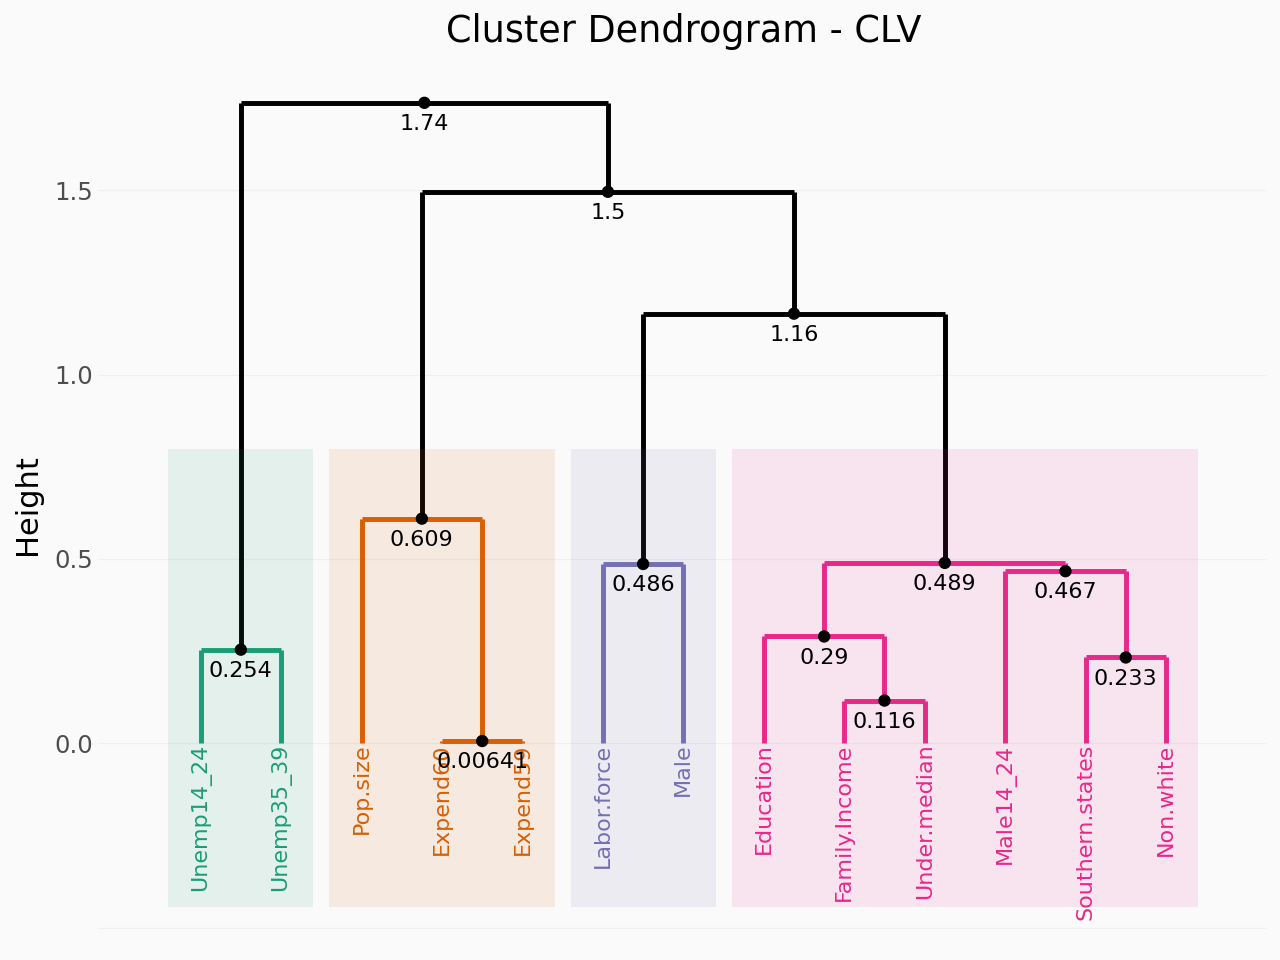

None


In [23]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.03)
print(p.show())

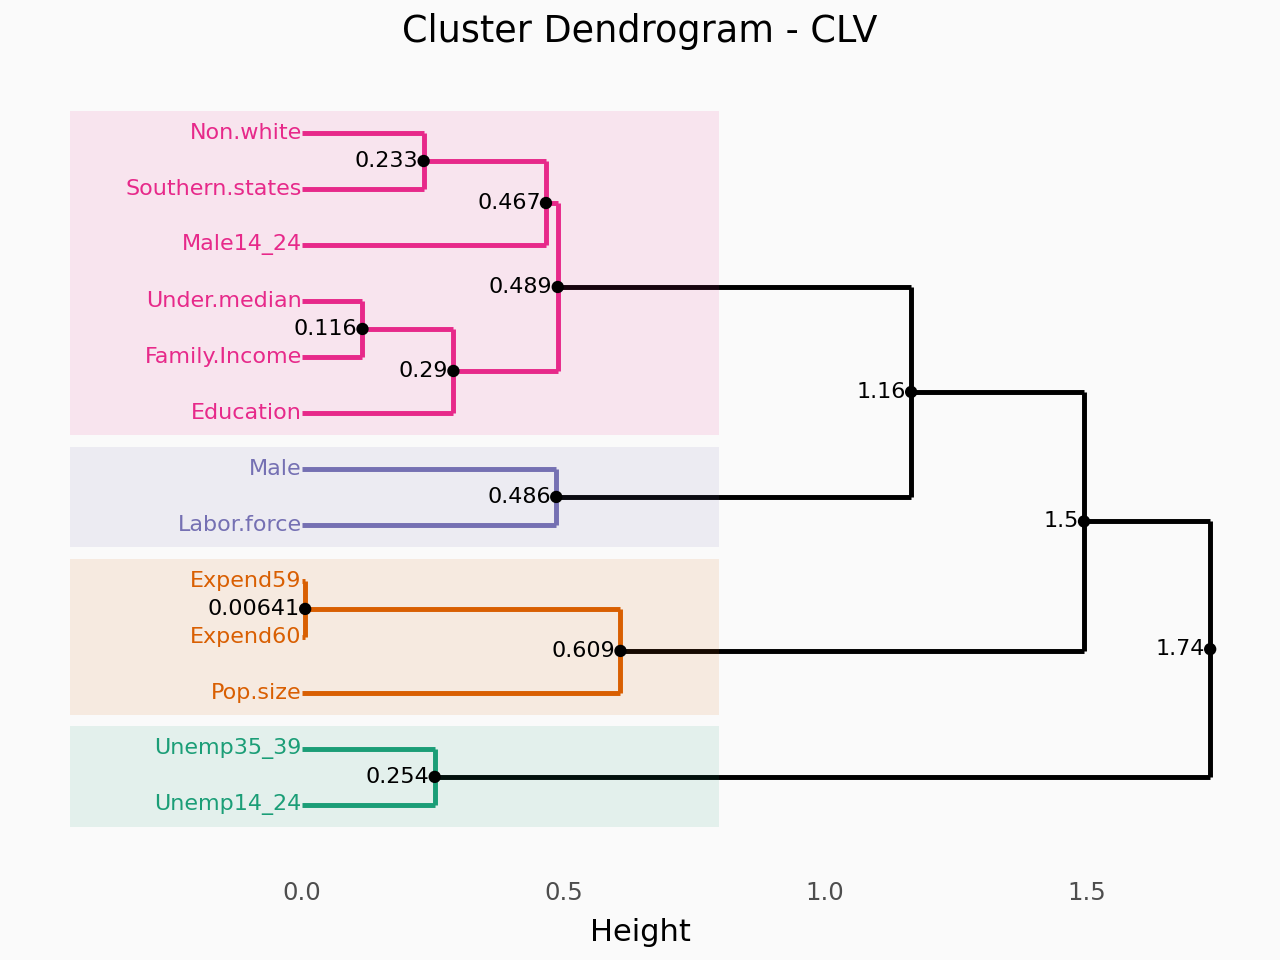

None


In [24]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.01)
print(p.show())

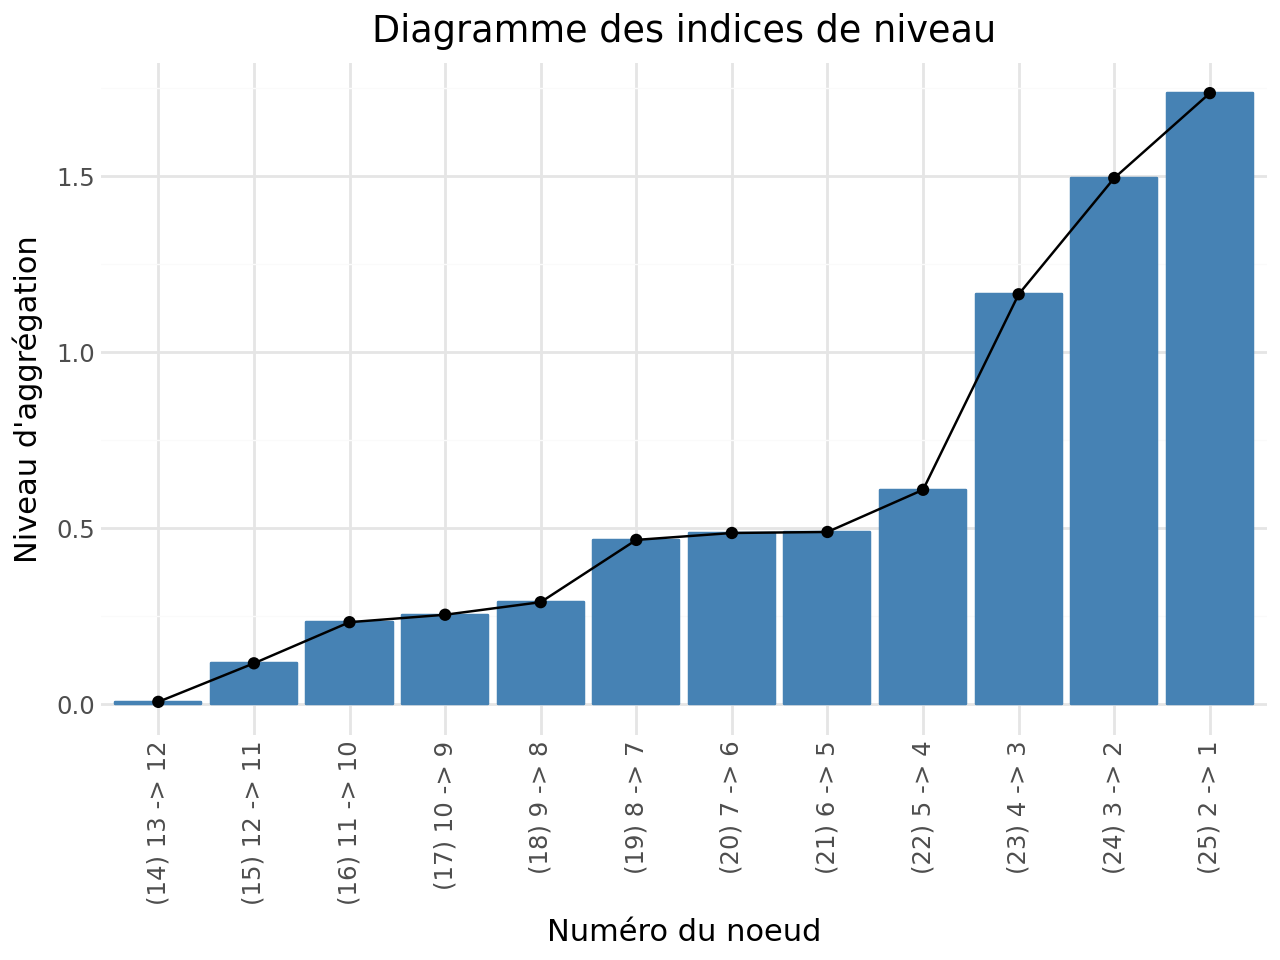

None


In [25]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Supplementary variables informations

In [26]:
# supplementary variables informations
var_sup_ = clf.var_sup_
var_sup_._fields

('cluster', 'cor', 'cortest', 'sqload', 'member')

### Cluster

In [27]:
# cluster
var_sup_.cluster.to_frame()

,cluster
Crime.rate,2


### Cluster correlations

In [28]:
# cluster correlations
var_sup_.cor

,1,2,3,4
Crime.rate,-0.067879,0.650248,0.231502,0.216227


### Cluster relationship

In [29]:
# cluster relationship
var_sup_.cortest

,variable,cluster,r,r**2,t,Pr(>|t|)
0,Crime.rate,1,-0.067879,0.004608,-0.456401,6.502967e-01
1,Crime.rate,2,0.650248,0.422822,5.741566,7.541695e-07
2,Crime.rate,3,0.231502,0.053593,1.596325,1.174161e-01
3,Crime.rate,4,0.216227,0.046754,1.485639,1.443473e-01


### Cluster squared loadings

In [30]:
# cluster squared loadings - supplementary variables
var_sup_.sqload

,1,2,3,4
Crime.rate,0.004608,0.422822,0.053593,0.046754


### Cluster member

In [31]:
# cluster member
var_sup_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,1 - R**2 Ratio
0,Crime.rate,2,0.422822,0.053593,0.609862


## Summary

In [32]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - CLV Results                     

Cluster Summary for 4 Clusters:
  Cluster  Members  Variation Explained  Proportion Explained
0       1        2             1.745925              0.872962
1       2        3             2.384314              0.794771
2       3        2             1.513559              0.756779
3       4        6             4.405141              0.734190

Inter-cluster Correlations:
          1         2         3         4
1  1.000000 -0.093814  0.097491 -0.061746
2 -0.093814  1.000000 -0.027182  0.516900
3  0.097491 -0.027182  1.000000  0.403296
4 -0.061746  0.516900  0.403296  1.000000

Cluster R-square:
                      1       2       3       4
Male14_24        0.0631  0.2473  0.0119  0.5988
Southern.states  0.0029  0.1011  0.2222  0.7441
Education        0.0112  0.1537  0.3291  0.7396
Expend60         0.0057  0.9334  0.0080  0.3436
Expend59         0.0040  0.9261  0.0055  0.3569
Labor.force      0.1211  0.0030

In [33]:
# summary with detailed
summary(clf,detailed=True)

                     Clustering of Variables - CLV Results                     

Cluster Summary for 4 Clusters:
  Cluster  Members  Variation Explained  Proportion Explained
0       1        2             1.745925              0.872962
1       2        3             2.384314              0.794771
2       3        2             1.513559              0.756779
3       4        6             4.405141              0.734190

Inter-cluster Correlations:
          1         2         3         4
1  1.000000 -0.093814  0.097491 -0.061746
2 -0.093814  1.000000 -0.027182  0.516900
3  0.097491 -0.027182  1.000000  0.403296
4 -0.061746  0.516900  0.403296  1.000000

Linear coefficients:
                        1         2          3         4
const            6.660505 -4.072635 -33.769486  0.729446
Male14_24             NaN       NaN        NaN -0.029653
Southern.states       NaN       NaN        NaN -0.867334
Education             NaN       NaN        NaN  0.037024
Expend60              NaN  0.02

In [34]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - CLV Results                     

Cluster Summary for 4 Clusters:
      Cluster    Members    Variation Explained    Proportion Explained
--  ---------  ---------  ---------------------  ----------------------
 0          1          2                1.74592                0.872962
 1          2          3                2.38431                0.794771
 2          3          2                1.51356                0.756779
 3          4          6                4.40514                0.73419

Inter-cluster Correlations:
             1           2           3           4
--  ----------  ----------  ----------  ----------
 1   1          -0.0938144   0.097491   -0.0617458
 2  -0.0938144   1          -0.0271824   0.5169
 3   0.097491   -0.0271824   1           0.403296
 4  -0.0617458   0.5169      0.403296    1

Cluster R-square:
                      1       2       3       4
---------------  ------  ------  ------  ------
Male14_24        0

In [35]:
# markdown formatting
summary(clf,detailed=True,to_markdown=True)

                     Clustering of Variables - CLV Results                     

Cluster Summary for 4 Clusters:
      Cluster    Members    Variation Explained    Proportion Explained
--  ---------  ---------  ---------------------  ----------------------
 0          1          2                1.74592                0.872962
 1          2          3                2.38431                0.794771
 2          3          2                1.51356                0.756779
 3          4          6                4.40514                0.73419

Inter-cluster Correlations:
             1           2           3           4
--  ----------  ----------  ----------  ----------
 1   1          -0.0938144   0.097491   -0.0617458
 2  -0.0938144   1          -0.0271824   0.5169
 3   0.097491   -0.0271824   1           0.403296
 4  -0.0617458   0.5169      0.403296    1

Linear coefficients:
                           1            2            3             4
---------------  -----------  ----------- 